# Support Vector Machines (SVM) Tutorial
## Kernel Selection and Hyperparameter Tuning with make_classification

This notebook provides a detailed, step-by-step explanation of how SVM works, how kernel choice affects decision boundaries, and how hyperparameters impact model performance.

## 1. Introduction to SVM
Support Vector Machines (SVMs) are supervised learning algorithms used for classification tasks.

Key ideas:
- Find a decision boundary (hyperplane)
- Maximize the margin between classes
- Use kernels to handle non-linear data

This notebook explores both theoretical concepts and practical implementation.

## 2. Import Libraries

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

## 3. Dataset Generation
We use `make_classification`, which creates a synthetic dataset similar to real-world data.

Key parameters:
- n_features=2 → allows visualization
- n_informative=2 → useful features
- class_sep=1.5 → controls separation difficulty


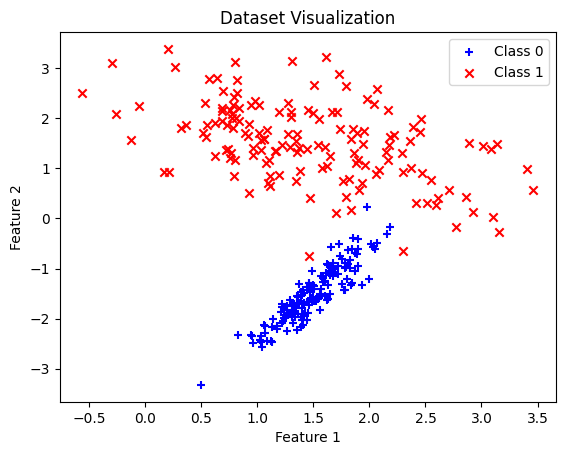

<Figure size 640x480 with 0 Axes>

In [44]:
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1,
                           class_sep=1.5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

plt.figure()

# Separate classes
class_0 = y == 0
class_1 = y == 1

# Plot with BOTH color + marker differences
plt.scatter(X[class_0, 0], X[class_0, 1],
            color='blue', marker='+', label='Class 0')  # blue +

plt.scatter(X[class_1, 0], X[class_1, 1],
            color='red', marker='x', label='Class 1')  # red x

plt.title('Dataset Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()
plt.savefig('dataset_visualization.png')

#Important:Data points are set to + and x which can be easily detected by color blind people and class lables are also friendly for detecting data points.

## 4. Decision Boundary Visualization
This function plots how the model separates classes. It helps us visually understand model behavior.

In [36]:
def plot_decision_boundary(model, ax, title):
    model.fit(X_train, y_train)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Colorblind-friendly background (blue & orange)
    ax.contourf(xx, yy, Z, alpha=0.3,
                levels=[-0.5, 0.5, 1.5],
                colors=['blue', 'orange'])

    # Separate classes
    class_0 = y == 0
    class_1 = y == 1

    # Plot with BOTH color + marker differences
    ax.scatter(X[class_0, 0], X[class_0, 1],
               color='red', marker='+',
               label='Class 0')

    ax.scatter(X[class_1, 0], X[class_1, 1],
               color='black', marker='x',
               label='Class 1')

    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend()


## 5. Kernel Comparison
We compare three kernels:
- Linear: simple boundary
- Polynomial: curved boundary
- RBF: flexible boundary

This helps us understand how model complexity affects performance.

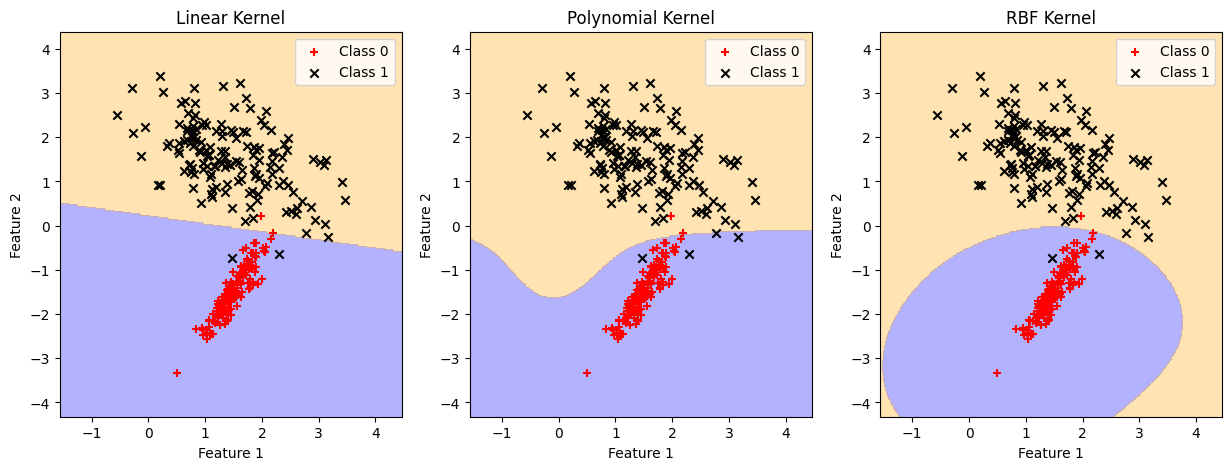

<Figure size 640x480 with 0 Axes>

In [45]:
models = [
    svm.SVC(kernel='linear'),
    svm.SVC(kernel='poly', degree=3),
    svm.SVC(kernel='rbf')
]

titles = ['Linear Kernel', 'Polynomial Kernel', 'RBF Kernel']

fig, axes = plt.subplots(1, 3, figsize=(15,5))
for model, ax, title in zip(models, axes, titles):
    plot_decision_boundary(model, ax, title)

plt.show()
plt.savefig('kernel_comparison.png')

## 6. Hyperparameter Tuning
SVM performance depends heavily on hyperparameters:

- C: controls margin vs misclassification
- gamma: controls influence of points (RBF)

We use GridSearchCV to find optimal values.

In [38]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.01, 0.1, 1],
    'kernel': ['rbf']
}

grid = GridSearchCV(svm.SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)

print('Best Parameters:', grid.best_params_)

Best Parameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}


## 7. Model Evaluation
We evaluate the tuned model using classification metrics.

In [39]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        46
           1       0.98      1.00      0.99        44

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90



## 8. Accuracy Comparison Across Kernels
This plot compares how different kernels perform on the same dataset.

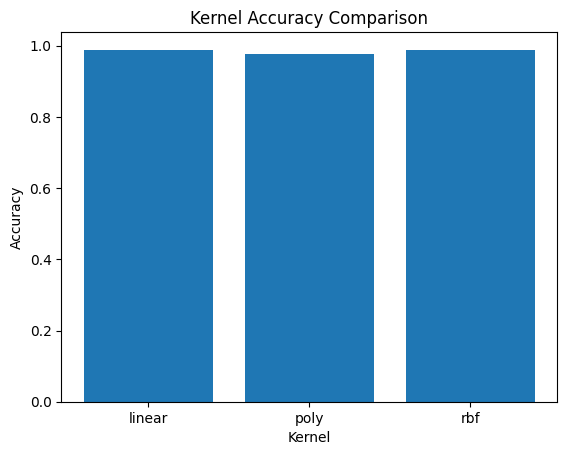

<Figure size 640x480 with 0 Axes>

In [46]:
kernels = ['linear', 'poly', 'rbf']
accuracies = []

for k in kernels:
    model = svm.SVC(kernel=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure()
plt.bar(kernels, accuracies)
plt.title('Kernel Accuracy Comparison')
plt.xlabel('Kernel')
plt.ylabel('Accuracy')
plt.show()
plt.savefig('kernel_accuracy_comparison.png')

In [41]:
for k, acc in zip(kernels, accuracies):
    print(f"{k}: {acc:.3f}")


linear: 0.989
poly: 0.978
rbf: 0.989


## 9. Hyperparameter Accuracy Heatmap
This heatmap shows how accuracy changes with different C and gamma values.
It helps identify underfitting and overfitting regions.

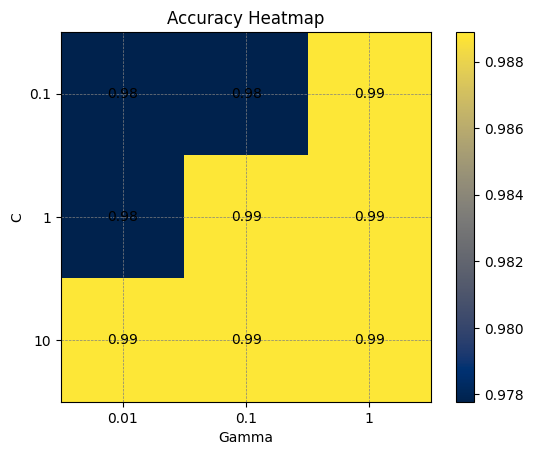

<Figure size 640x480 with 0 Axes>

In [47]:
C_vals = [0.1, 1, 10]
gamma_vals = [0.01, 0.1, 1]

acc_matrix = np.zeros((len(C_vals), len(gamma_vals)))

for i, C in enumerate(C_vals):
    for j, g in enumerate(gamma_vals):
        model = svm.SVC(kernel='rbf', C=C, gamma=g)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc_matrix[i, j] = accuracy_score(y_test, y_pred)

plt.figure()

# Use colorblind-friendly colormap
im = plt.imshow(acc_matrix, cmap='cividis')

# Adding text annotations with contrast-aware color
for i in range(len(C_vals)):
    for j in range(len(gamma_vals)):
        value = acc_matrix[i, j]
        text_color = 'white' if value < acc_matrix.max()/2 else 'black'
        plt.text(j, i, f'{value:.2f}',
                 ha='center', va='center',
                 color=text_color)

plt.xticks(range(len(gamma_vals)), gamma_vals)
plt.yticks(range(len(C_vals)), C_vals)
plt.xlabel('Gamma')
plt.ylabel('C')
plt.title('Accuracy Heatmap')
plt.colorbar(im)

# Adding grid lines for readability for colourblind people
plt.grid(which='both', color='gray', linestyle='--', linewidth=0.5)
plt.show()
plt.savefig('hyperparameter_heatmap.png')

## 10. Conclusion
This notebook demonstrated:
- Kernel effects on decision boundaries
- Importance of hyperparameter tuning
- Visualization of model performance

SVM is a powerful and flexible algorithm when properly tuned.